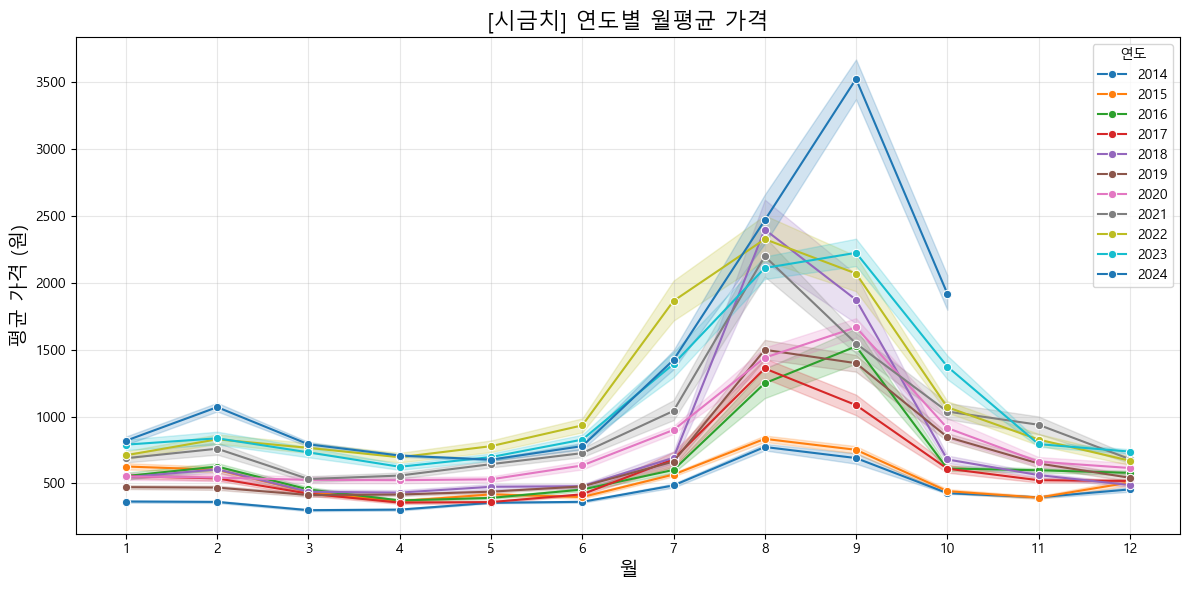

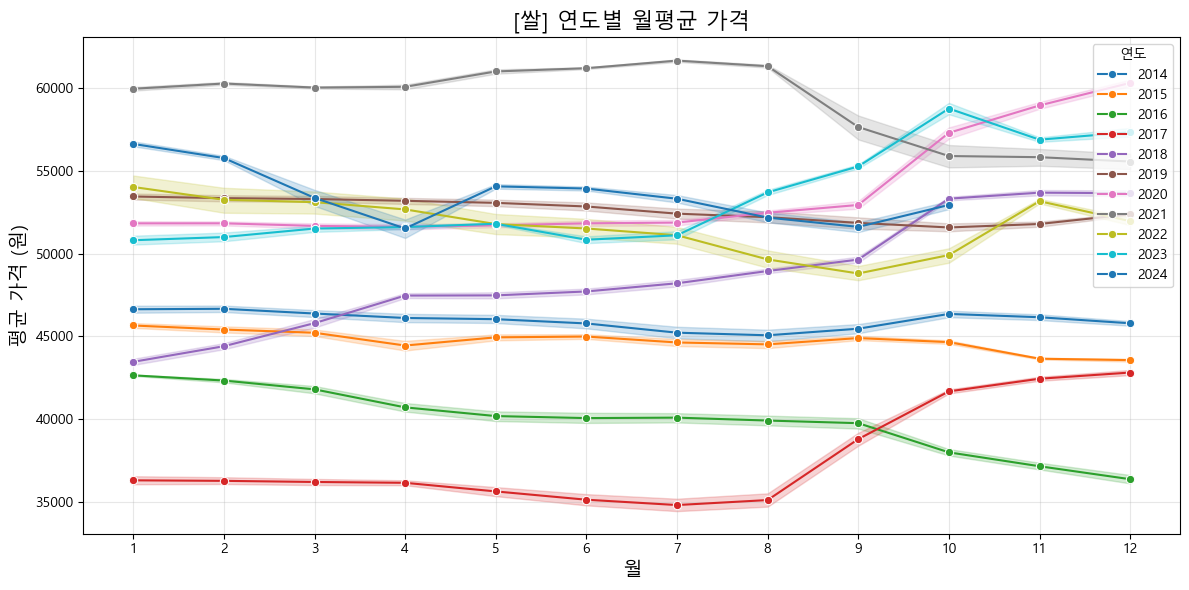

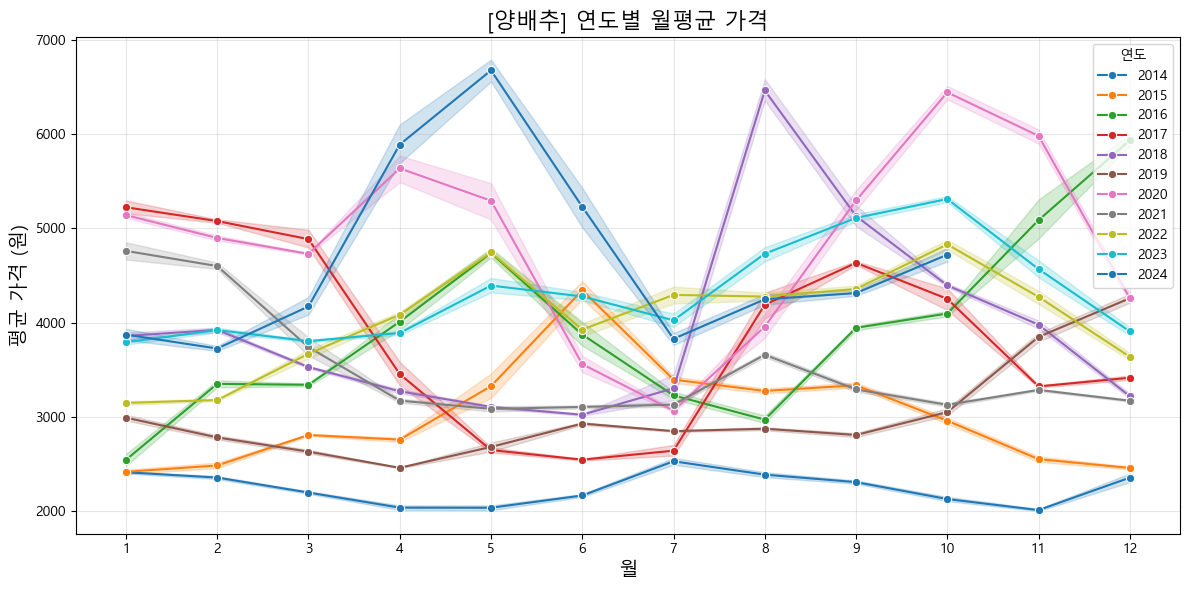

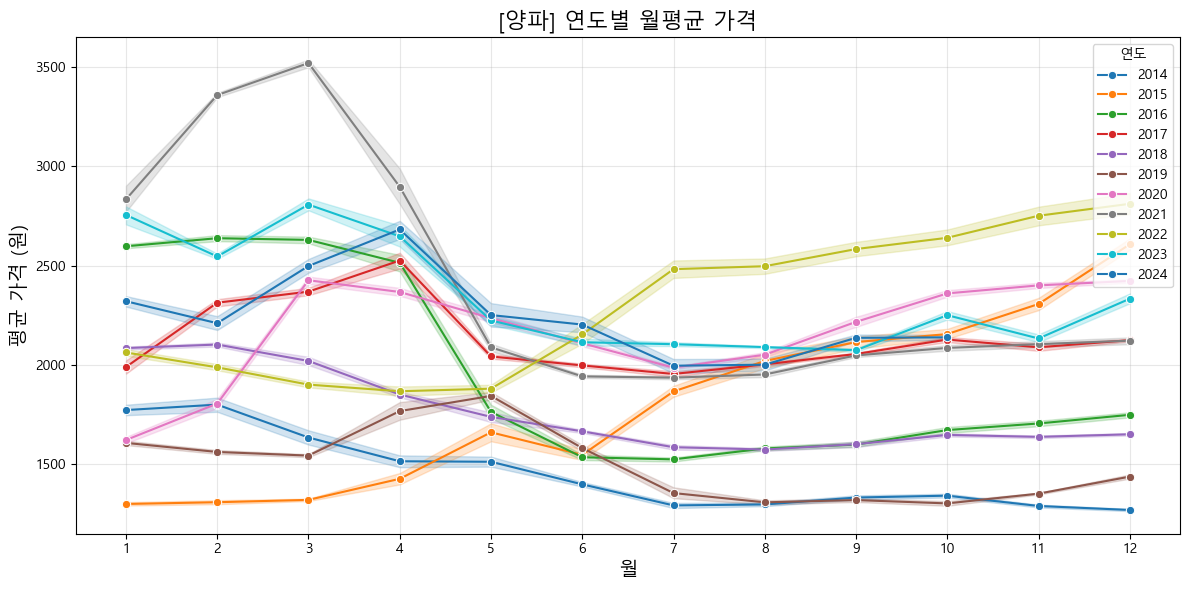

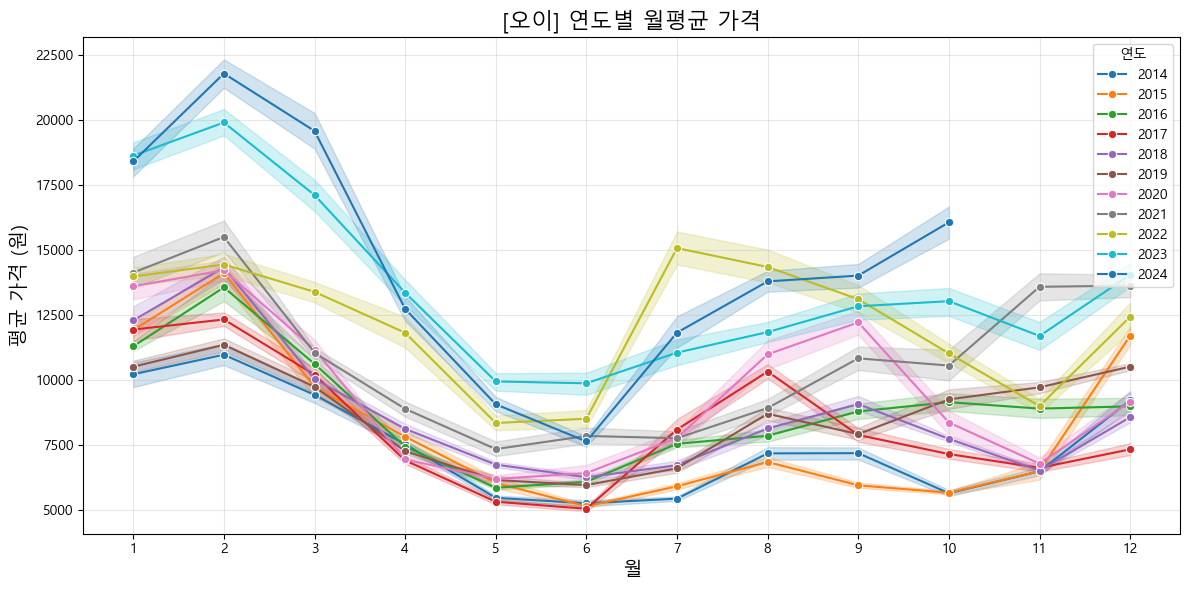

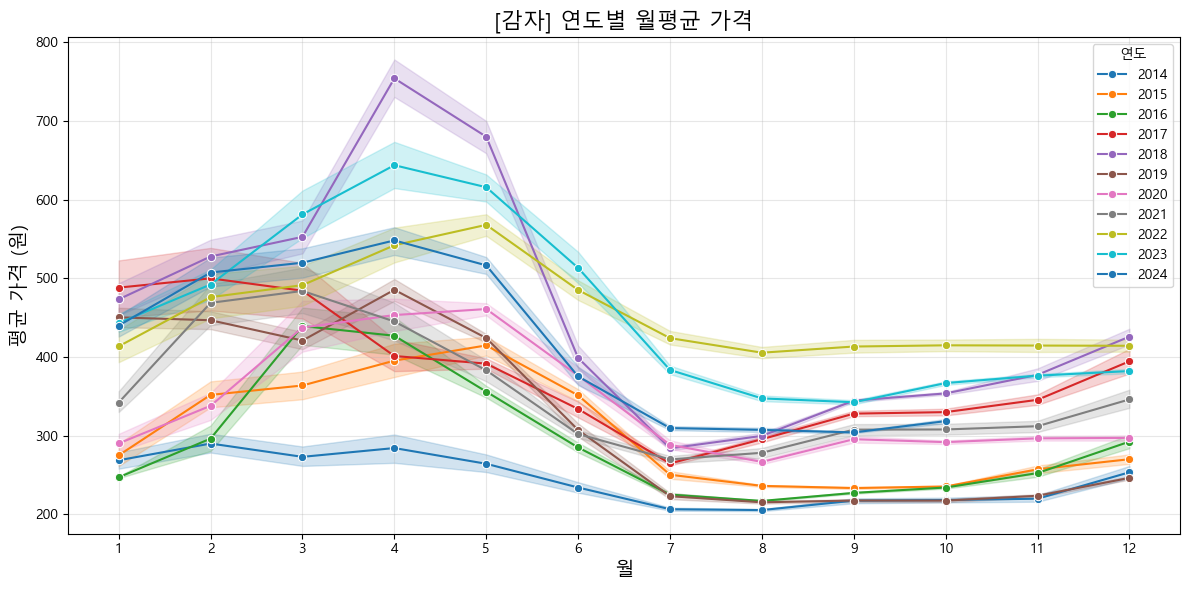

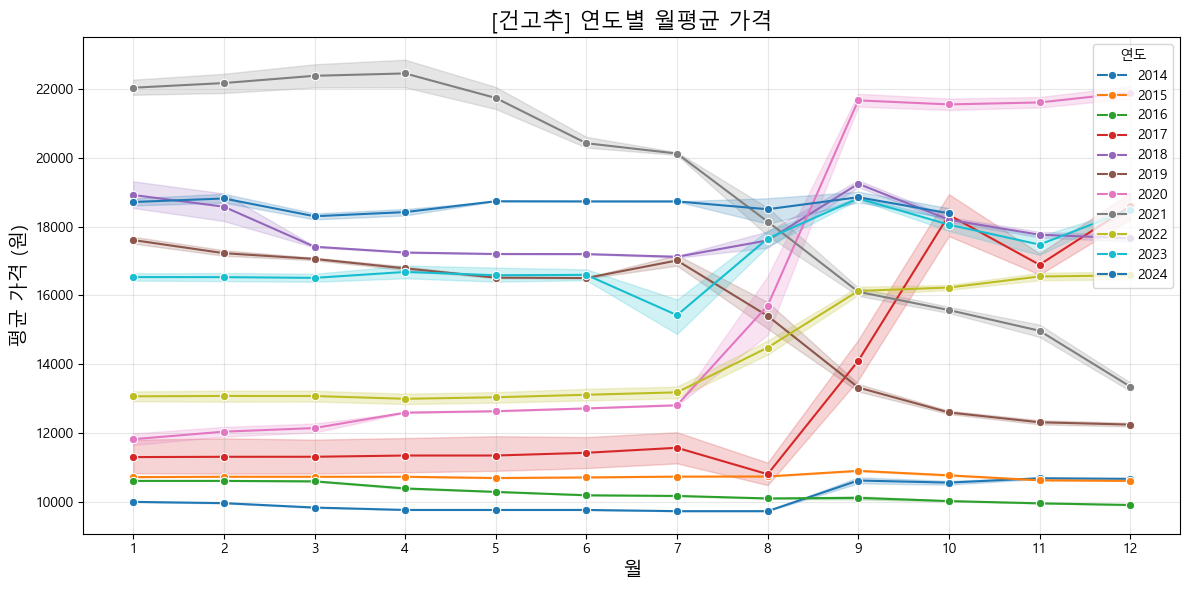

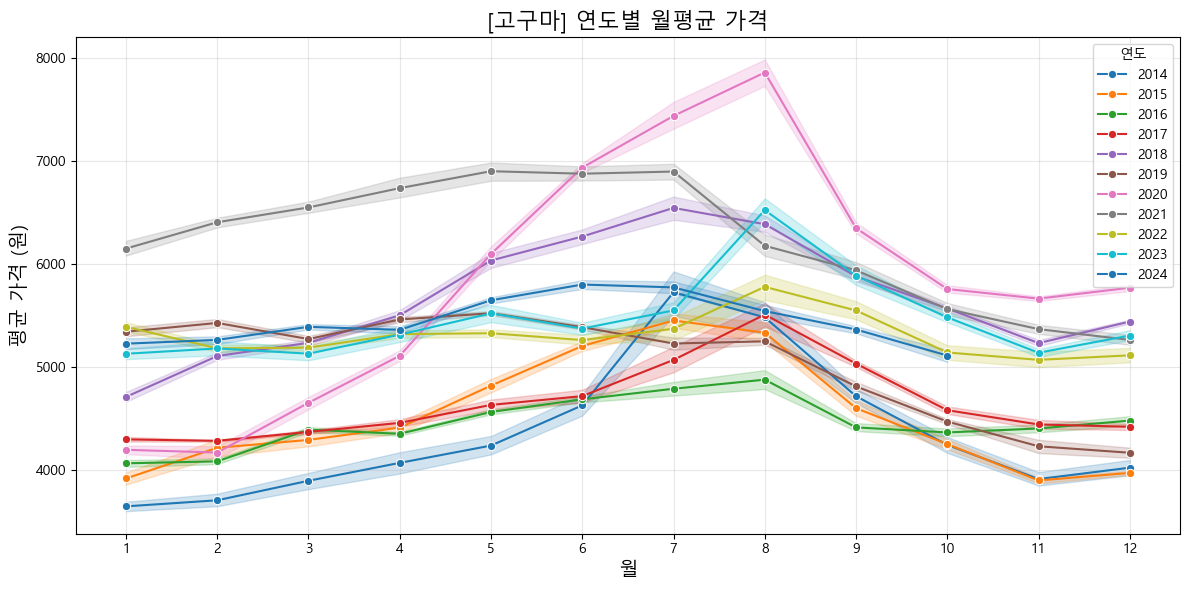

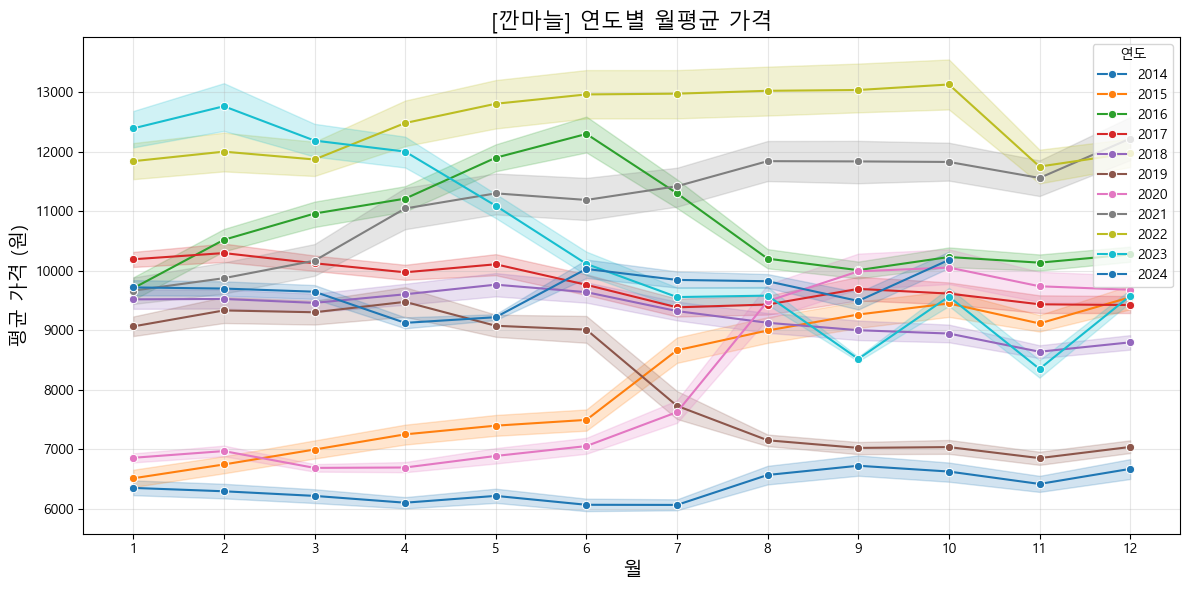

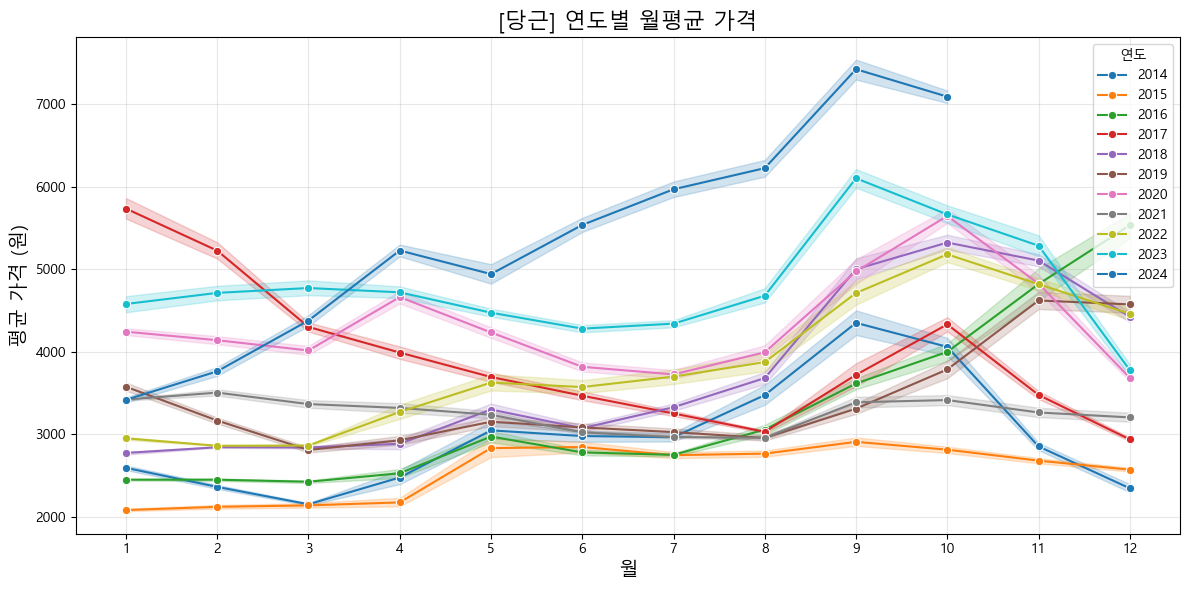

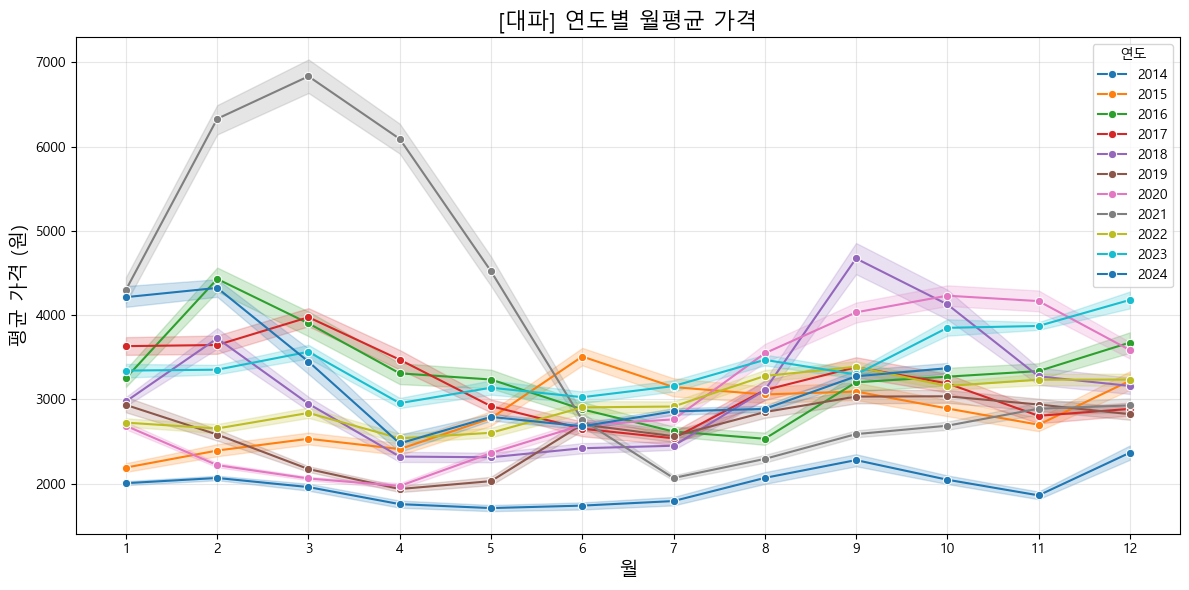

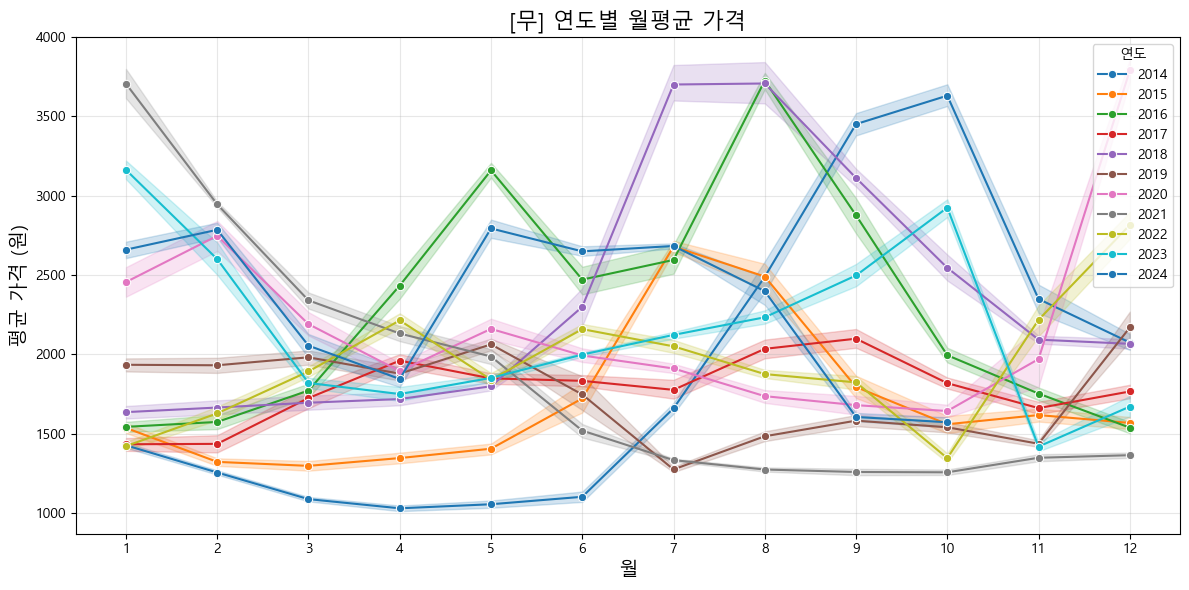

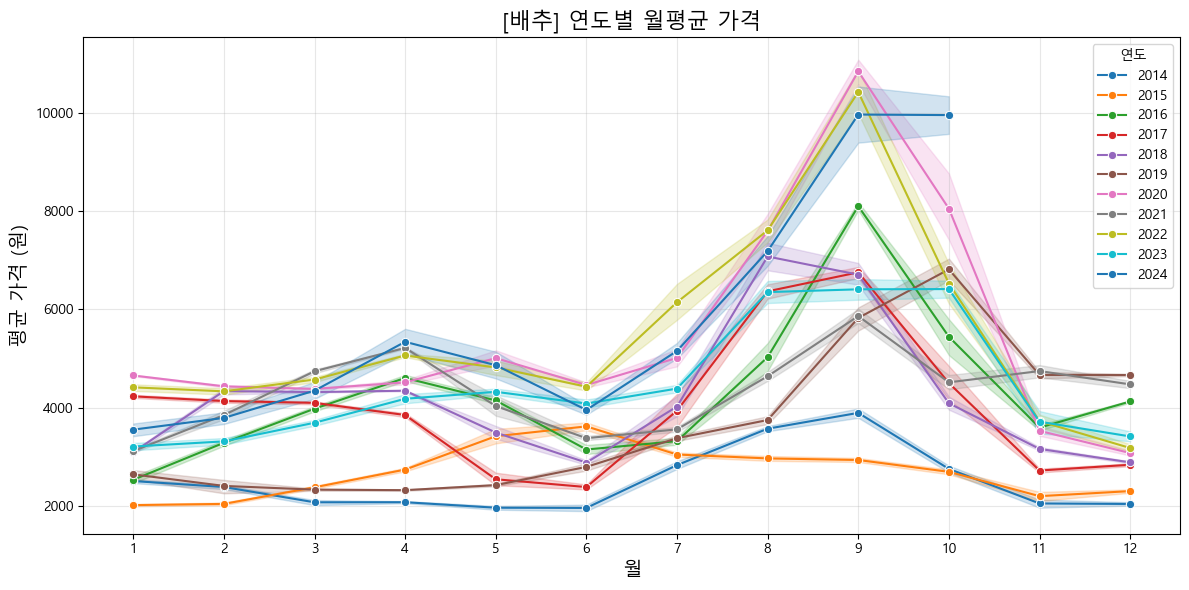

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc

# 한글 폰트 설정 (Windows의 'Malgun Gothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 데이터 파일 경로 (사용자가 원하는 품목만 추가)
file_paths = {
    '시금치': 'C:\\Users\\정태빈\\Downloads\\채소사는날\\채소사는날\\식품예측 데이터\\일별소매가\\시금치_상품_100g_일별소매가.csv',
    '쌀': 'C:\\Users\\정태빈\\Downloads\\채소사는날\\채소사는날\\식품예측 데이터\\일별소매가\\쌀_상품_일별소매가.csv',
    '양배추': 'C:\\Users\\정태빈\\Downloads\\채소사는날\\채소사는날\\식품예측 데이터\\일별소매가\\양배추_상품_1포기_일별소매가.csv',
    '양파': 'C:\\Users\\정태빈\\Downloads\\채소사는날\\채소사는날\\식품예측 데이터\\일별소매가\\양파_상품_1kg_일별소매가.csv',
    '오이': 'C:\\Users\\정태빈\\Downloads\\채소사는날\\채소사는날\\식품예측 데이터\\일별소매가\\오이_상품_10개_일별소매가.csv',
    '감자': 'C:\\Users\\정태빈\\Downloads\\채소사는날\\채소사는날\\식품예측 데이터\\일별소매가\\감자_상품_100g_일별소매가.csv',
    '건고추': 'C:\\Users\\정태빈\\Downloads\\채소사는날\\채소사는날\\식품예측 데이터\\일별소매가\\건고추_상품_600g_일별소매가.csv',
    '고구마': 'C:\\Users\\정태빈\\Downloads\\채소사는날\\채소사는날\\식품예측 데이터\\일별소매가\\고구마_상품_1kg_일별소매가.csv',
    '깐마늘': 'C:\\Users\\정태빈\\Downloads\\채소사는날\\채소사는날\\식품예측 데이터\\일별소매가\\깐마늘_상품_1kg_일별소매가.csv',
    '당근': 'C:\\Users\\정태빈\\Downloads\\채소사는날\\채소사는날\\식품예측 데이터\\일별소매가\\당근_상품_1kg_일별소매가.csv',
    '대파': 'C:\\Users\\정태빈\\Downloads\\채소사는날\\채소사는날\\식품예측 데이터\\일별소매가\\대파_상품_1kg_일별소매가.csv',
    '무': 'C:\\Users\\정태빈\\Downloads\\채소사는날\\채소사는날\\식품예측 데이터\\일별소매가\\무_상품_1개_일별소매가.csv',
    '배추': 'C:\\Users\\정태빈\\Downloads\\채소사는날\\채소사는날\\식품예측 데이터\\일별소매가\\배추_상품_1포기_일별소매가.csv'
    # 추가적으로 원하는 품목을 여기에 입력
}

# 데이터를 통합할 리스트
dataframes = []

# 데이터 로드 및 전처리
for name, path in file_paths.items():
    df = pd.read_csv(path, encoding='cp949', thousands=',')  # CP949 인코딩
    df = df.rename(columns={'구분': '날짜'})  # 날짜 컬럼 이름 통일
    df['날짜'] = pd.to_datetime(df['날짜'], errors='coerce')  # 날짜 변환
    df = df.melt(id_vars=['날짜'], var_name='판매처', value_name='가격')  # 가로 데이터를 세로로 변환
    df['품목'] = name  # 품목 추가
    dataframes.append(df)

# 데이터프레임 통합
merged_df = pd.concat(dataframes, ignore_index=True)
merged_df['가격'] = pd.to_numeric(merged_df['가격'], errors='coerce')  # 가격 숫자형 변환
merged_df['연도'] = merged_df['날짜'].dt.year  # 연도 추출
merged_df['월'] = merged_df['날짜'].dt.month  # 월 추출

# 월별 평균 가격 계산
df_monthly = merged_df.groupby(['연도', '월']).mean(numeric_only=True).reset_index()

# 각 품목에 대해 그래프 생성
for name in file_paths.keys():
    # 해당 품목만 필터링
    df_filtered = merged_df[merged_df['품목'] == name]

    # 스타일 설정 및 그래프 생성
    plt.figure(figsize=(12, 6))
    palette = sns.color_palette("tab10", len(df_filtered['연도'].unique()))  # 연도별 색상 구분

    sns.lineplot(
        data=df_filtered,
        x='월', 
        y='가격', 
        hue='연도', 
        palette=palette,  # 색상 팔레트
        marker='o'        # 데이터 포인트 표시
    )

    # 그래프 제목 및 레이블 설정
    plt.title(f"[{name}] 연도별 월평균 가격", fontsize=16)
    plt.xlabel("월", fontsize=14)
    plt.ylabel("평균 가격 (원)", fontsize=14)
    plt.xticks(range(1, 13))  # 월 범위 설정
    plt.grid(alpha=0.3)

    # 범례 및 레이아웃
    plt.legend(title="연도", loc='upper right', fontsize=10)
    plt.tight_layout()

    # 그래프 표시
    plt.show()

#선 주변에 색상이 칠해진 영역은 **신뢰 구간(confidence interval)**을 나타냅니다.
#Seaborn의 sns.lineplot에서는 기본적으로 선 위에 95% 신뢰 구간을 표시하는 기능이 있습니다.
#이는 각 데이터 포인트에서의 평균 값에 대한 변동 범위를 시각적으로 보여줍니다.
